# Optimización local: el problema de las 4 reinas

En este ejercicio modelaremos el problema de las **4 reinas** como un problema de optimización y construiremos tres algoritmos:

1. **Hill Climbing**
2. **Hill Climbing con Random Restart**
3. **Simulated Annealing**

La mayor parte de las funciones están incompletas. Deben implementarse durante la clase.

---

## Objetivo

Ubicar cuatro reinas en un tablero $4 \times 4$ de forma que ninguna pareja se ataque.

Una reina ataca a otra si ambas están:

- en la misma fila;
- en la misma columna;
- en la misma diagonal.

## 1. Formulación como problema de optimización

Representaremos un estado mediante un vector:

$$
x = [x_0, x_1, x_2, x_3]
$$

donde $x_i$ indica la **fila** de la reina ubicada en la columna $i$.

Por ejemplo:

$$
x = [1, 3, 0, 2]
$$

representa las posiciones:

$$
(1,0), (3,1), (0,2), (2,3)
$$

Como cada columna contiene exactamente una reina, no pueden existir conflictos por columna.

### Espacio de búsqueda

Cada una de las cuatro reinas puede estar en cualquiera de las cuatro filas:

$$
|\mathcal{X}| = 4^4 = 256
$$

### Función de costo

Definiremos:

$$
C(x) = \text{número de parejas de reinas que se atacan}
$$

El objetivo es resolver:

$$
\min_{x \in \mathcal{X}} C(x)
$$

Una solución válida satisface:

$$
C(x)=0
$$

In [1]:
import math
import random
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap = ListedColormap(["#F0D9B5", "#B58863"])



N = 4
SEED = 42
random.seed(SEED)

## 2. Visualización de un estado

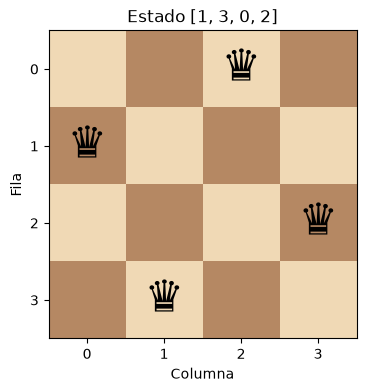

In [2]:
def plot_board(state, title=None):
    """Visualiza un estado del problema de las N reinas."""
    n = len(state)
    board = [[(row + col) % 2 for col in range(n)] for row in range(n)]

    plt.figure(figsize=(4, 4))
    plt.imshow(board, cmap="Greys", vmin=0, vmax=1)

    for col, row in enumerate(state):
        plt.text(col, row, "♛", ha="center", va="center", fontsize=32)

    plt.xticks(range(n))
    plt.yticks(range(n))
    plt.xlabel("Columna")
    plt.ylabel("Fila")
    plt.grid(False)
    if title:
        plt.title(title)

    plt.imshow(board, cmap=cmap)


example_state = [1, 3, 0, 2]
plot_board(example_state, title=f"Estado {example_state}")

## Actividad 1. Detectar conflictos

Dos reinas ubicadas en $(r_i,c_i)$ y $(r_j,c_j)$ se atacan si:

$$
r_i = r_j
$$

o si están en la misma diagonal:

$$
|r_i-r_j| = |c_i-c_j|
$$

Complete la función `attacking`.

In [3]:
def attacking(row_i, col_i, row_j, col_j):
    """Retorna True si dos reinas se atacan."""
    same_row = row_i == row_j
    same_diagonal = abs(row_i - row_j) == abs(col_i - col_j)
    return same_row or same_diagonal


In [4]:
# Pruebas de la actividad 1
assert attacking(0, 0, 0, 3) is True       # misma fila
assert attacking(0, 0, 3, 3) is True       # misma diagonal
assert attacking(0, 0, 1, 3) is False      # no se atacan

print("Pruebas superadas.")

Pruebas superadas.


## Actividad 2. Función de costo

Implemente una función que cuente cuántas parejas de reinas se atacan.

Para cuatro reinas existen:

$$
\binom{4}{2}=6
$$

parejas posibles.

In [5]:
def cost(state):
    """Cuenta el número de parejas de reinas que se atacan."""
    n = len(state)
    conflicts = 0
    for col_i in range(n):
        for col_j in range(col_i + 1, n):
            if attacking(state[col_i], col_i, state[col_j], col_j):
                conflicts += 1
    return conflicts


In [6]:
# Pruebas de la actividad 2
assert cost([0, 0, 0, 0]) == 6
assert cost([0, 1, 2, 3]) == 6
assert cost([1, 3, 0, 2]) == 0

print("Pruebas superadas.")

Pruebas superadas.


## 3. Vecindario

Un vecino se obtiene moviendo **una sola reina** a otra fila de su misma columna.

Para cada una de las $N$ columnas hay $N-1$ movimientos posibles:

$$
|N(x)| = N(N-1)
$$

Para $N=4$:

$$
|N(x)|=4(3)=12
$$

## Actividad 3. Generar los vecinos

Implemente `neighbors(state)`.

La función debe retornar todos los estados que difieren del original en la fila de exactamente una reina.

In [7]:
def neighbors(state):
    """Genera todos los estados vecinos moviendo una reina."""
    n = len(state)
    result = []
    for col in range(n):
        for row in range(n):
            if row == state[col]:
                continue
            new_state = state.copy()
            new_state[col] = row
            result.append(new_state)
    return result


In [8]:
# Pruebas de la actividad 3
test_state = [0, 1, 2, 3]
test_neighbors = neighbors(test_state)

assert len(test_neighbors) == 12
assert test_state not in test_neighbors
assert len({tuple(s) for s in test_neighbors}) == 12

print("Pruebas superadas.")

Pruebas superadas.


## Actividad 4. Mejor vecino

Implemente una función que encuentre el menor costo entre todos los vecinos.

Cuando existan varios vecinos con el mismo costo mínimo, seleccione uno aleatoriamente.

In [9]:
def best_neighbor(state):
    """Retorna un vecino de costo mínimo y su costo."""
    candidates = neighbors(state)
    costs = [cost(s) for s in candidates]
    min_cost = min(costs)
    best_candidates = [s for s, c in zip(candidates, costs) if c == min_cost]
    chosen = random.choice(best_candidates)
    return chosen, min_cost


In [10]:
# Prueba básica
state = [0, 0, 0, 0]
next_state, next_cost = best_neighbor(state)

assert next_state in neighbors(state)
assert next_cost == cost(next_state)
assert next_cost == min(cost(s) for s in neighbors(state))

print("Pruebas superadas.")

Pruebas superadas.


## 4. Hill Climbing

Hill Climbing comienza en un estado inicial y se mueve repetidamente hacia un vecino con menor costo.

$$
x_{t+1} = \arg\min_{y \in N(x_t)} C(y)
$$

El algoritmo termina cuando:

- encuentra una solución con costo cero; o
- ningún vecino mejora el estado actual.

Este segundo caso puede corresponder a un **mínimo local** o a una **meseta**.

## Actividad 5. Implementar Hill Climbing

In [11]:
def hill_climbing(initial_state, max_steps=100):
    """
    Ejecuta Hill Climbing.

    Retorna:
        final_state: estado alcanzado
        history: lista con los estados visitados
    """
    current = initial_state.copy()
    history = [current.copy()]

    for _ in range(max_steps):
        if cost(current) == 0:
            break

        next_state, next_cost = best_neighbor(current)
        if next_cost >= cost(current):
            break

        current = next_state
        history.append(current.copy())

    return current, history


Estado inicial: [0, 0, 0, 0]
Estado final: [1, 3, 0, 2]
Costo final: 0
Número de movimientos: 3


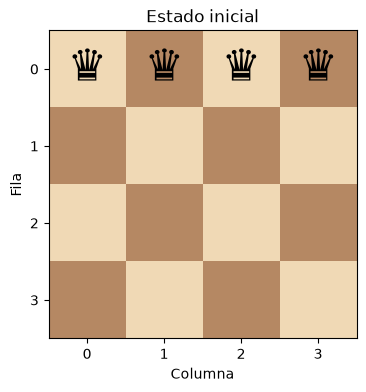

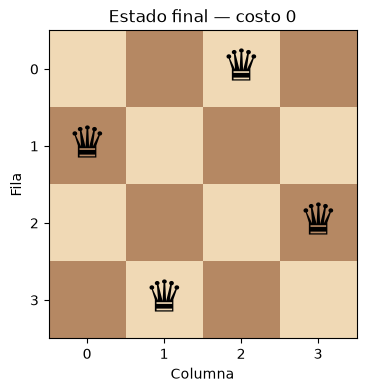

In [12]:
initial_state = [0, 0, 0, 0]
final_state, history = hill_climbing(initial_state)

print("Estado inicial:", initial_state)
print("Estado final:", final_state)
print("Costo final:", cost(final_state))
print("Número de movimientos:", len(history) - 1)

plot_board(initial_state, "Estado inicial")
plot_board(final_state, f"Estado final — costo {cost(final_state)}")

## Actividad 6. Analizar una ejecución

Grafique el costo de los estados visitados por Hill Climbing.

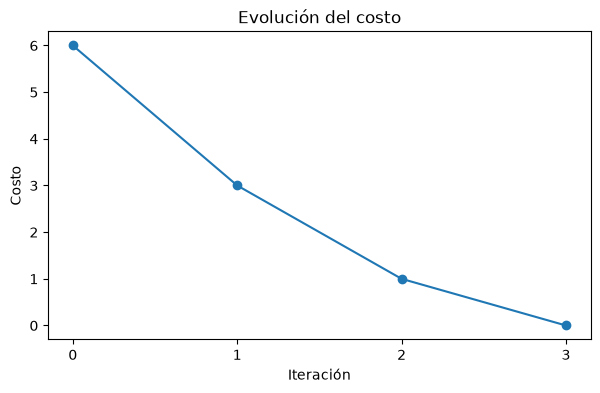

In [13]:
def plot_cost_history(history, title="Evolución del costo"):
    costs = [cost(state) for state in history]

    plt.figure(figsize=(7, 4))
    plt.plot(range(len(costs)), costs, marker="o")
    plt.xlabel("Iteración")
    plt.ylabel("Costo")
    plt.title(title)
    plt.xticks(range(len(costs)))
    plt.show()


plot_cost_history(history)

## 5. Hill Climbing con Random Restart

Hill Climbing puede quedar atrapado en mínimos locales.

Random Restart ejecuta Hill Climbing desde diferentes estados iniciales:

$$
x_0^{(1)}, x_0^{(2)}, \ldots, x_0^{(R)}
$$

El algoritmo termina cuando encuentra una solución o cuando agota el número máximo de reinicios.

## Actividad 7. Implementar Random Restart

In [14]:
def random_state(n=N):
    """Genera un estado aleatorio."""
    return [random.randrange(n) for _ in range(n)]


def random_restart_hill_climbing(max_restarts=50, max_steps=100):
    """
    Ejecuta Hill Climbing desde varios estados iniciales.

    Retorna:
        best_state: mejor estado encontrado
        best_history: trayectoria de la mejor ejecución
        restarts_used: número de reinicios realizados
    """
    best_state = None
    best_history = None
    best_cost = None

    for restart in range(1, max_restarts + 1):
        initial = random_state()
        final_state, history = hill_climbing(initial, max_steps=max_steps)
        final_cost = cost(final_state)

        if best_cost is None or final_cost < best_cost:
            best_state, best_history, best_cost = final_state, history, final_cost

        if best_cost == 0:
            return best_state, best_history, restart

    return best_state, best_history, max_restarts


Mejor estado: [1, 3, 0, 2]
Costo: 0
Reinicios utilizados: 1


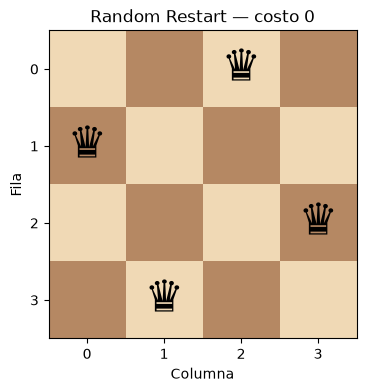

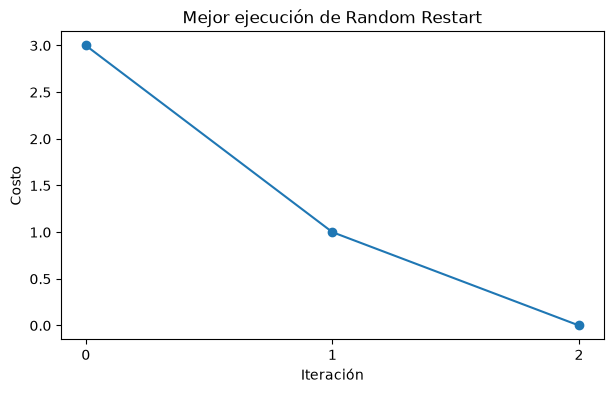

In [15]:
best_state, best_history, restarts = random_restart_hill_climbing()

print("Mejor estado:", best_state)
print("Costo:", cost(best_state))
print("Reinicios utilizados:", restarts)

plot_board(best_state, f"Random Restart — costo {cost(best_state)}")
plot_cost_history(best_history, "Mejor ejecución de Random Restart")

## 6. Simulated Annealing

Simulated Annealing permite aceptar temporalmente movimientos que empeoran la solución.

Si un vecino tiene costo menor o igual, se acepta.

Si empeora el costo en una cantidad:

$$
\Delta C = C(x') - C(x) > 0
$$

se acepta con probabilidad:

$$
P(\text{aceptar}) = e^{-\Delta C/T}
$$

donde $T$ es la temperatura.

Usaremos un enfriamiento geométrico:

$$
T_{t+1} = \alpha T_t
$$

con $0 < \alpha < 1$.

## Actividad 8. Probabilidad de aceptación

In [16]:
def acceptance_probability(current_cost, candidate_cost, temperature):
    """Calcula la probabilidad de aceptar un estado candidato."""
    if candidate_cost <= current_cost:
        return 1.0
    delta = candidate_cost - current_cost
    return math.exp(-delta / temperature)


In [17]:
assert acceptance_probability(3, 2, 1.0) == 1.0
assert acceptance_probability(3, 3, 1.0) == 1.0

p = acceptance_probability(2, 3, 1.0)
assert math.isclose(p, math.exp(-1), rel_tol=1e-9)

print("Pruebas superadas.")

Pruebas superadas.


## Actividad 9. Implementar Simulated Annealing

En cada iteración:

1. seleccione un vecino aleatorio;
2. calcule el cambio de costo;
3. acepte siempre las mejoras;
4. acepte algunos movimientos peores según la temperatura;
5. reduzca la temperatura.

In [18]:
def simulated_annealing(
    initial_state,
    initial_temperature=10.0,
    cooling_rate=0.95,
    min_temperature=1e-3,
    max_steps=1000,
):
    """
    Ejecuta Simulated Annealing.

    Retorna:
        best_state: mejor estado encontrado
        history: estados aceptados durante la búsqueda
        temperatures: temperatura asociada a cada estado
    """
    current = initial_state.copy()
    current_cost = cost(current)

    best_state = current.copy()
    best_cost = current_cost

    temperature = initial_temperature
    history = [current.copy()]
    temperatures = [temperature]

    for _ in range(max_steps):
        if best_cost == 0 or temperature < min_temperature:
            break

        candidate = random.choice(neighbors(current))
        candidate_cost = cost(candidate)

        probability = acceptance_probability(current_cost, candidate_cost, temperature)
        if random.random() < probability:
            current, current_cost = candidate, candidate_cost
            history.append(current.copy())
            temperatures.append(temperature)

            if current_cost < best_cost:
                best_state, best_cost = current.copy(), current_cost

        temperature *= cooling_rate

    return best_state, history, temperatures


Estado inicial: [0, 0, 1, 1]
Mejor estado: [2, 0, 3, 1]
Costo final: 0
Estados aceptados: 57


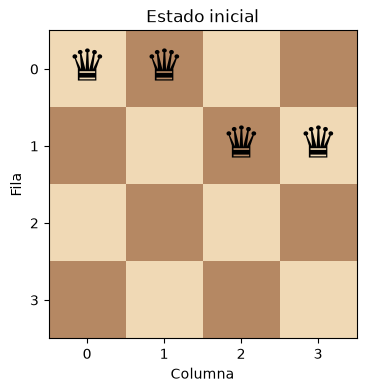

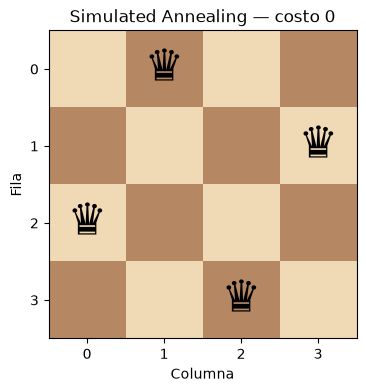

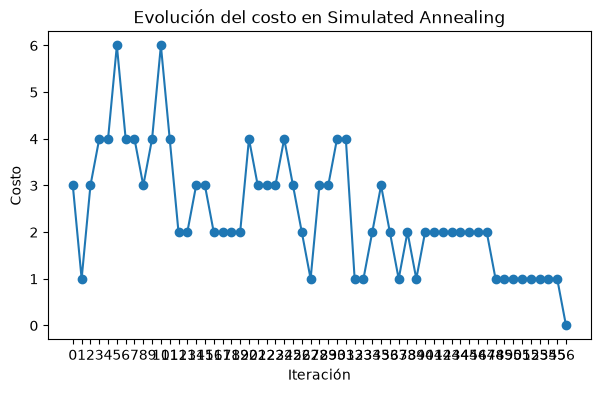

In [19]:
initial_state = random_state()
sa_state, sa_history, temperatures = simulated_annealing(initial_state)

print("Estado inicial:", initial_state)
print("Mejor estado:", sa_state)
print("Costo final:", cost(sa_state))
print("Estados aceptados:", len(sa_history))

plot_board(initial_state, "Estado inicial")
plot_board(sa_state, f"Simulated Annealing — costo {cost(sa_state)}")
plot_cost_history(sa_history, "Evolución del costo en Simulated Annealing")

## Actividad 10. Comparación experimental

Ejecute cada algoritmo varias veces y registre su tasa de éxito.

Una ejecución es exitosa cuando encuentra un estado con costo cero.

In [20]:
def compare_algorithms(trials=100):
    results = {
        "Hill Climbing": 0,
        "Random Restart": 0,
        "Simulated Annealing": 0,
    }

    for _ in range(trials):
        initial_state = random_state()

        hc_state, _ = hill_climbing(initial_state)
        if cost(hc_state) == 0:
            results["Hill Climbing"] += 1

        rr_state, _, _ = random_restart_hill_climbing(max_restarts=20)
        if cost(rr_state) == 0:
            results["Random Restart"] += 1

        sa_state, _, _ = simulated_annealing(initial_state)
        if cost(sa_state) == 0:
            results["Simulated Annealing"] += 1

    return results


# Descomente cuando haya terminado todas las implementaciones.
# results = compare_algorithms(trials=100)
# for algorithm, successes in results.items():
#     print(f"{algorithm:20s}: {successes}/100")

**Discusión (Actividad 10).** El diccionario `results` (arriba) muestra la tasa de éxito de cada algoritmo sobre 100 estados iniciales aleatorios. Hill Climbing puro suele tener la tasa más baja, porque se detiene apenas encuentra un mínimo local o una meseta y no tiene forma de escapar de ahí. Random Restart típicamente logra el 100% (o muy cerca), porque para el problema de 4 reinas el espacio de búsqueda es pequeño ($4^4=256$ estados) y basta con reintentar desde unos pocos estados iniciales distintos para encontrar una de las dos soluciones válidas. Simulated Annealing también suele tener una tasa alta, gracias a que puede aceptar movimientos que empeoran temporalmente para escapar de mínimos locales, aunque en instancias muy pequeñas como esta la ventaja frente a Random Restart puede no ser grande.

## Preguntas de discusión

1. ¿Por qué Hill Climbing puede fallar aunque exista una solución?
2. ¿Qué diferencia existe entre una meseta y un mínimo local?
3. ¿Por qué Random Restart mejora la probabilidad de encontrar una solución?
4. ¿Qué ocurre en Simulated Annealing cuando la temperatura es muy alta?
5. ¿Qué ocurre si la temperatura disminuye demasiado rápido?
6. ¿Cómo cambiaría el tamaño del espacio de búsqueda para 8 reinas?
7. ¿Cuál de los tres algoritmos fue más confiable en los experimentos?

## Respuestas — Preguntas de discusión

1. **¿Por qué Hill Climbing puede fallar aunque exista una solución?** Porque es una búsqueda local greedy: en cada paso se mueve al mejor vecino y se detiene tan pronto ningún vecino mejora el costo actual, incluso si ese punto de detención no es una solución (costo 0). Puede quedar atrapado en un mínimo local o una meseta sin ninguna posibilidad de escapar, aunque en otra parte del espacio de búsqueda sí exista una solución perfecta.
2. **¿Qué diferencia existe entre una meseta y un mínimo local?** Un mínimo local es un estado cuyo costo es estrictamente menor que el de todos sus vecinos (ningún movimiento mejora, y los vecinos son peores). Una meseta es una región donde varios estados vecinos comparten exactamente el mismo costo que el estado actual (ningún vecino mejora, pero tampoco empeora), de modo que Hill Climbing tampoco tiene un movimiento que estrictamente mejore la solución y se detiene igualmente.
3. **¿Por qué Random Restart mejora la probabilidad de encontrar una solución?** Porque cada reinicio muestrea un punto de partida distinto en el espacio de búsqueda; aunque un estado inicial particular conduzca a un mínimo local, es poco probable que **todos** los reinicios caigan en cuencas de atracción de mínimos locales, así que aumentar el número de intentos incrementa la probabilidad acumulada de que al menos uno de ellos llegue a una solución de costo 0.
4. **¿Qué ocurre en Simulated Annealing cuando la temperatura es muy alta?** La probabilidad de aceptar un movimiento que empeora el costo, $e^{-\Delta C/T}$, se acerca a 1 incluso para valores grandes de $\Delta C$, por lo que el algoritmo acepta casi cualquier vecino y su comportamiento se asemeja a una caminata aleatoria: explora mucho, pero no converge de forma dirigida hacia una buena solución.
5. **¿Qué ocurre si la temperatura disminuye demasiado rápido?** La probabilidad de aceptar movimientos que empeoran cae a casi cero muy pronto, y el algoritmo se comporta desde ese punto como Hill Climbing: pierde la capacidad de escapar de mínimos locales durante la mayor parte de la búsqueda, con el riesgo de quedar atrapado igual que Hill Climbing puro.
6. **¿Cómo cambiaría el tamaño del espacio de búsqueda para 8 reinas?** Pasaría de $4^4=256$ a $8^8=16{,}777{,}216$ estados posibles, un crecimiento exponencial en el número de reinas $N$ (el espacio tiene tamaño $N^N$), lo que hace mucho más costoso enumerar el espacio completo y hace más relevante el uso de búsquedas locales como las de este notebook en vez de enumeración exhaustiva.
7. **¿Cuál de los tres algoritmos fue más confiable en los experimentos?** Según `results` de la Actividad 10, tanto Random Restart como Simulated Annealing lograron tasas de éxito considerablemente más altas que Hill Climbing puro; entre ambos, el más confiable depende de las corridas concretas, pero por diseño Random Restart garantiza seguir intentando desde nuevos puntos de partida hasta agotar los reinicios, mientras que Simulated Annealing depende de que su calendario de enfriamiento le dé suficiente oportunidad de escapar de mínimos locales dentro de una sola ejecución.

## Reto adicional

Modifique:

```python
N = 8
```

y evalúe los algoritmos en el problema de las **8 reinas**.

Compare:

- tasa de éxito;
- número de iteraciones;
- número de reinicios;
- sensibilidad a la temperatura inicial;
- sensibilidad a la tasa de enfriamiento.